# 2D Ising quench dynamics

Computes
$$\langle Z \rangle = \langle 0 | U^{\dag} Z U | 0 \rangle$$
where $Z$ corresponds to Pauli Z operator on central site, $| 0 \rangle$ is the all-zero initial state, and $U = e^{-i H t}$ is the evolution under the 2D transverse-field Ising Hamiltonian
$$H = - \sum_{\langle i, j \rangle} Z_i Z_j - h_c \sum_i X_i $$
with open boundary conditions and critical point $h_c = 3.044382$.

In [2]:
import sys
sys.path.append('../')
from spd.SparsePauliDynamics import *

import numpy as np
import itertools
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cmx

In [3]:
#Generate neighbor list
def neighbor_list(n):
    nq = n**2
    return nq, [(i,j) for i,j in itertools.combinations(range(nq), 2) if abs(i-j)%n + abs(i//n-j//n)==1]

In [ ]:
n=11
hc = 3.044382
h = hc
nq, nlist = neighbor_list(n)
print(nq, nlist)
hx = SparsePauliOp.from_sparse_list([('Z', [i], -h) for i in range(nq)], num_qubits=nq)
hzz = SparsePauliOp.from_sparse_list([('XX', pair, -1.0) for pair in nlist], num_qubits=nq)
h_tot = hzz + hx
print('2D Ising: ', h_tot)
obs = SparsePauliOp.from_sparse_list([('Z', [(nq-1)//2], 1.0)], num_qubits=nq)

121 [(0, 1), (0, 11), (1, 2), (1, 12), (2, 3), (2, 13), (3, 4), (3, 14), (4, 5), (4, 15), (5, 6), (5, 16), (6, 7), (6, 17), (7, 8), (7, 18), (8, 9), (8, 19), (9, 10), (9, 20), (10, 21), (11, 12), (11, 22), (12, 13), (12, 23), (13, 14), (13, 24), (14, 15), (14, 25), (15, 16), (15, 26), (16, 17), (16, 27), (17, 18), (17, 28), (18, 19), (18, 29), (19, 20), (19, 30), (20, 21), (20, 31), (21, 32), (22, 23), (22, 33), (23, 24), (23, 34), (24, 25), (24, 35), (25, 26), (25, 36), (26, 27), (26, 37), (27, 28), (27, 38), (28, 29), (28, 39), (29, 30), (29, 40), (30, 31), (30, 41), (31, 32), (31, 42), (32, 43), (33, 34), (33, 44), (34, 35), (34, 45), (35, 36), (35, 46), (36, 37), (36, 47), (37, 38), (37, 48), (38, 39), (38, 49), (39, 40), (39, 50), (40, 41), (40, 51), (41, 42), (41, 52), (42, 43), (42, 53), (43, 54), (44, 45), (44, 55), (45, 46), (45, 56), (46, 47), (46, 57), (47, 48), (47, 58), (48, 49), (48, 59), (49, 50), (49, 60), (50, 51), (50, 61), (51, 52), (51, 62), (52, 53), (52, 63), (53,

In [5]:
obs_t = []
def exp_val_func(obs):
    obs_t.append(obs.copy())
    nonzero_pauli_indices = np.where(obs.ztype())[0]
    exp_val = np.sum(obs.coeffs[nonzero_pauli_indices] * evaluate_expectation_value_zero_state(obs, nonzero_pauli_indices))
    print(exp_val, obs.size())
    return exp_val

dt = 0.04
nsteps = int(0.6 / dt)
step = 1
threshold = 2.**-16
ops = dt*h_tot
sim = Simulation.from_pauli_list(obs, ops, threshold=threshold, nprocs=1)
r = sim.run_dynamics(nsteps, process=exp_val_func, process_every = step)
r = np.array(r)

(1+0j) 1


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(0.9872680689481188+0j) 86
(0.9527802865260737+0j) 423
(0.9062561268754112+3.4383364196431218e-18j) 1196
(0.8595564709202614+7.326011792214717e-18j) 2718
(0.8229751609186085+8.652538694146782e-18j) 6881
(0.8022521816656444+5.623458829924135e-18j) 15371
(0.7969637161598739-1.3782486997328352e-18j) 33120
(0.8017356305931461-1.0403122115065025e-17j) 65957
(0.809528973880784-1.9187650751605665e-17j) 127752
(0.8140914806996408-2.6366468708891212e-17j) 243869
(0.8145752322410063-3.4672657733892735e-17j) 448257
(0.8136584758600379-4.874265214066465e-17j) 738403
(0.8138240117338559-6.953305577630501e-17j) 1180306
(0.8185152330432861-9.81947162556374e-17j) 1809742
(0.8281172561219123-1.3302922170087296e-16j) 2673542


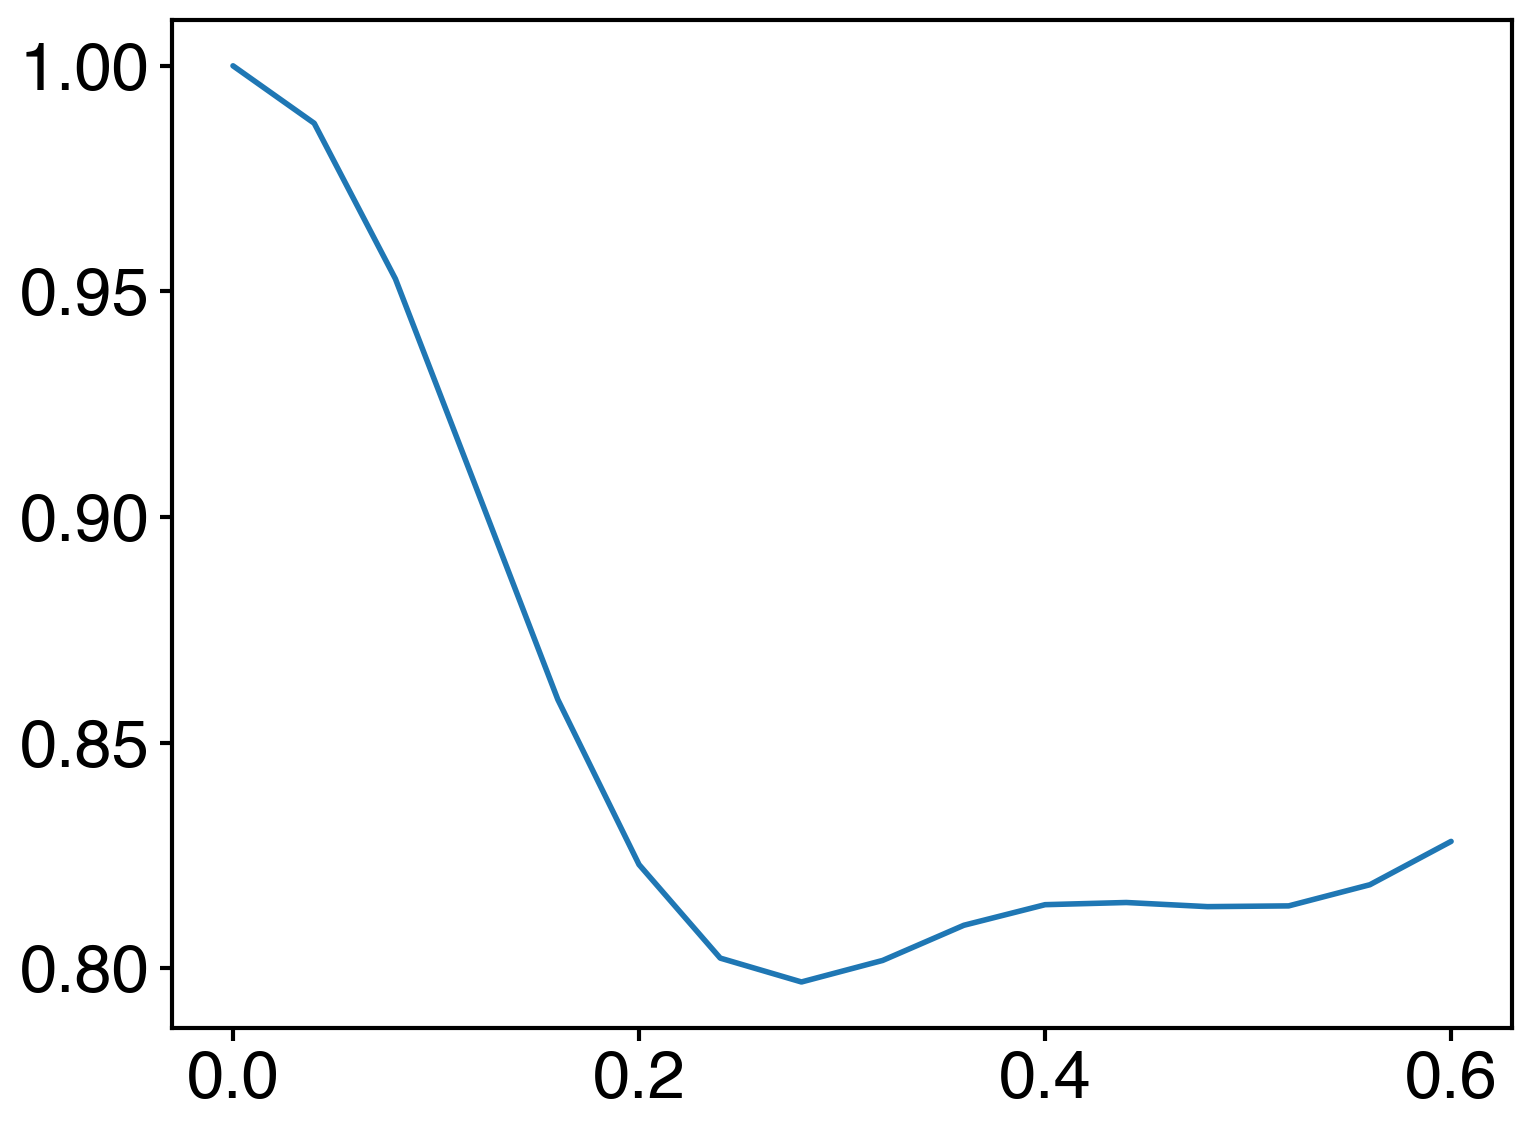

In [6]:
from quantum_simulation_recipe.plot_config import *
plt.plot(np.arange(len(r))*dt, r.real)
plt.show()

[(0, 1), (0, 11), (1, 2), (1, 12), (2, 3), (2, 13), (3, 4), (3, 14), (4, 5), (4, 15), (5, 6), (5, 16), (6, 7), (6, 17), (7, 8), (7, 18), (8, 9), (8, 19), (9, 10), (9, 20), (10, 21), (11, 12), (11, 22), (12, 13), (12, 23), (13, 14), (13, 24), (14, 15), (14, 25), (15, 16), (15, 26), (16, 17), (16, 27), (17, 18), (17, 28), (18, 19), (18, 29), (19, 20), (19, 30), (20, 21), (20, 31), (21, 32), (22, 23), (22, 33), (23, 24), (23, 34), (24, 25), (24, 35), (25, 26), (25, 36), (26, 27), (26, 37), (27, 28), (27, 38), (28, 29), (28, 39), (29, 30), (29, 40), (30, 31), (30, 41), (31, 32), (31, 42), (32, 43), (33, 34), (33, 44), (34, 35), (34, 45), (35, 36), (35, 46), (36, 37), (36, 47), (37, 38), (37, 48), (38, 39), (38, 49), (39, 40), (39, 50), (40, 41), (40, 51), (41, 42), (41, 52), (42, 43), (42, 53), (43, 54), (44, 45), (44, 55), (45, 46), (45, 56), (46, 47), (46, 57), (47, 48), (47, 58), (48, 49), (48, 59), (49, 50), (49, 60), (50, 51), (50, 61), (51, 52), (51, 62), (52, 53), (52, 63), (53, 54)

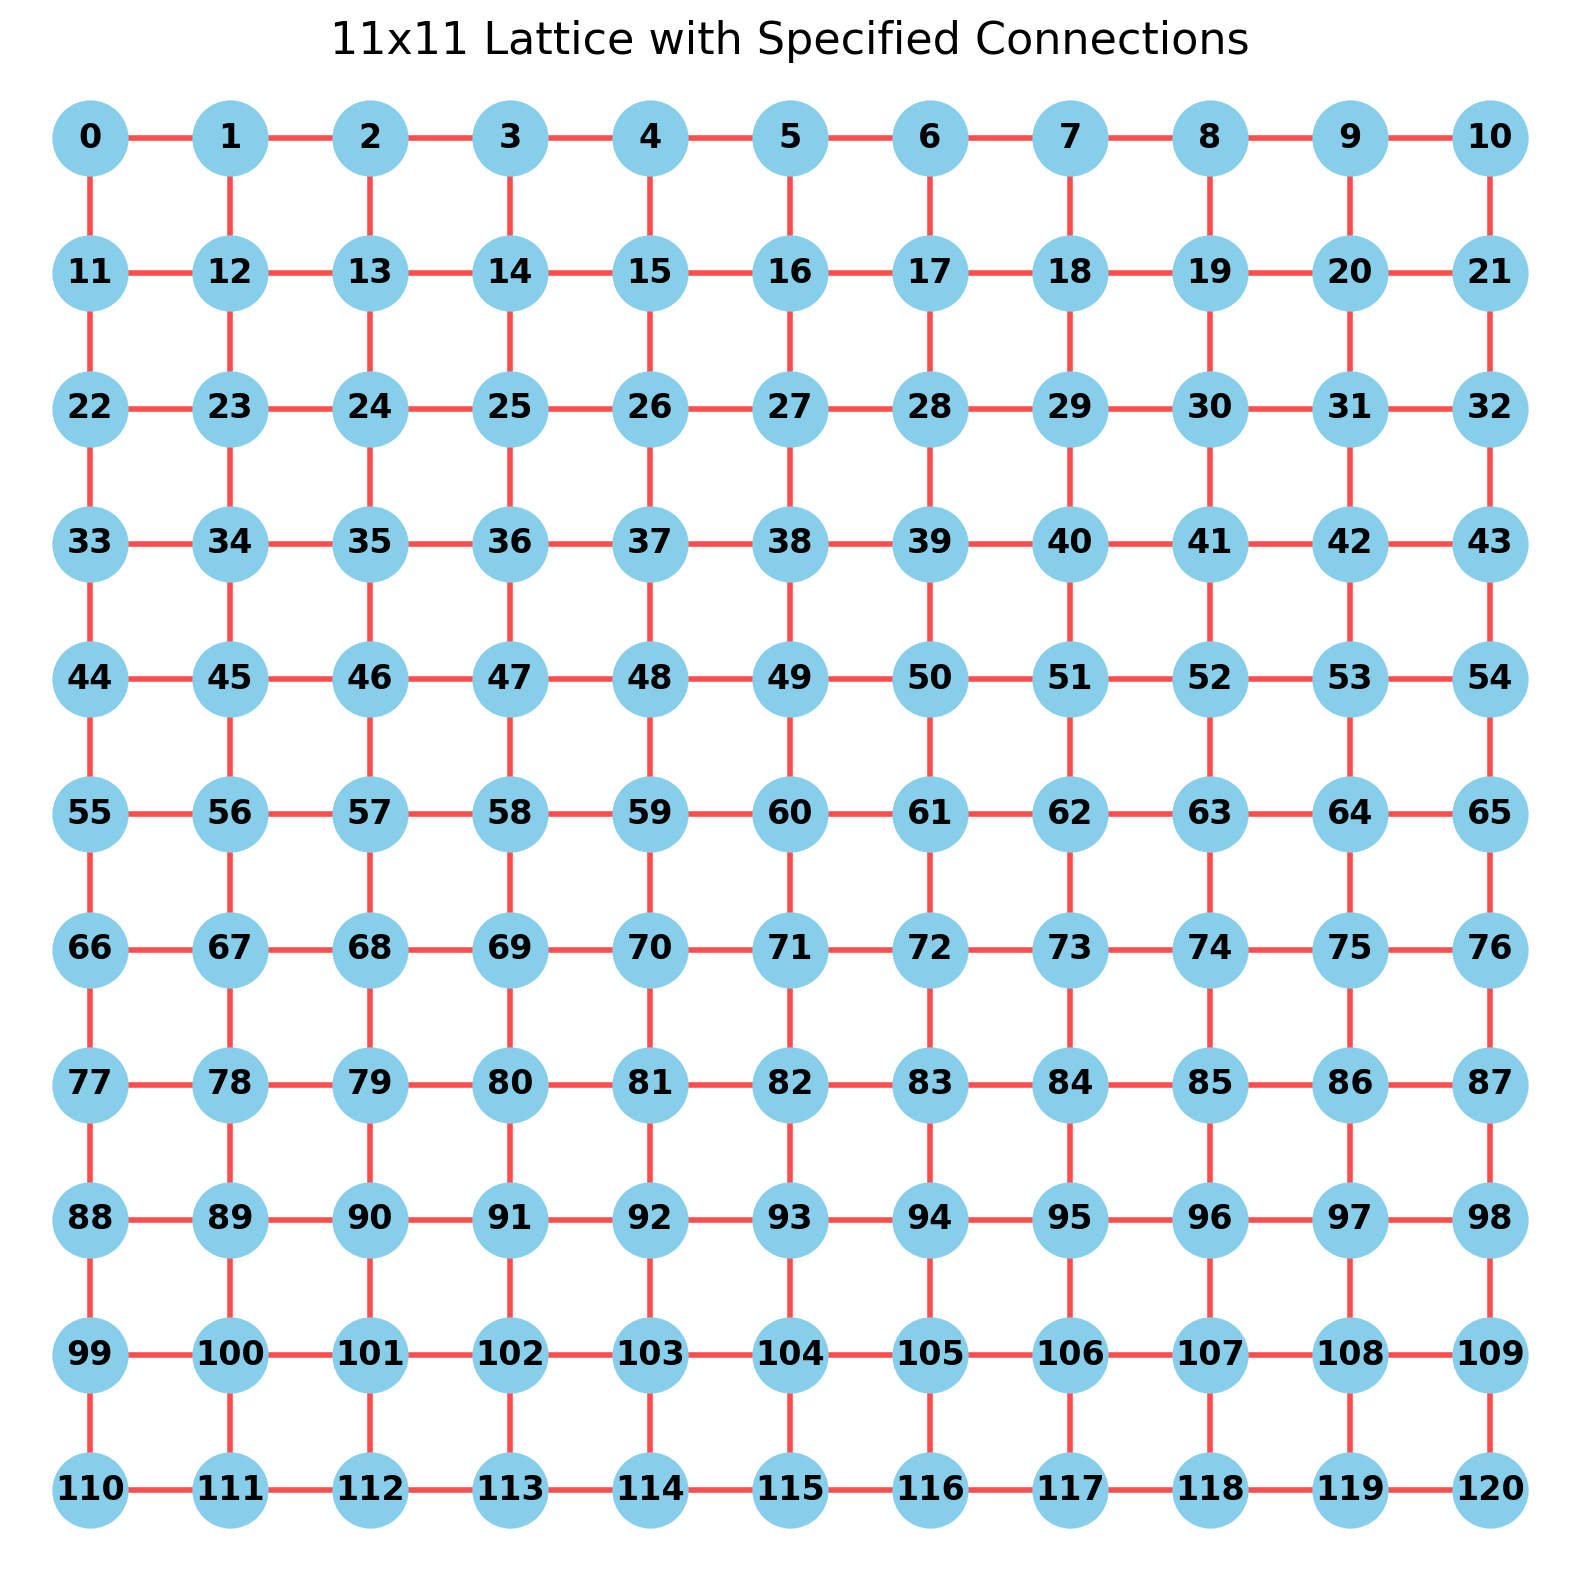

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def plot_lattice_networkx(n, edges):
    """
    Plot an n x n lattice with edges between specified node pairs using NetworkX.
    
    Parameters:
    -----------
    n : int
        Size of the lattice (n x n)
    edges : list of tuples
        List of (source, target) node pairs that have edges between them
    """
    # Create a graph
    G = nx.Graph()
    
    # Add nodes with positions
    pos = {}
    for i in range(n*n):
        row = i // n
        col = i % n
        # Add node
        G.add_node(i)
        # Store position (flipping y-axis for standard grid layout)
        pos[i] = (col, n - 1 - row)
    
    # Add edges
    G.add_edges_from(edges)
    
    # Create figure
    plt.figure(figsize=(8, 8))
    
    # Draw the nodes
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=700)
    
    # Draw the node labels
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    
    # Draw the edges
    nx.draw_networkx_edges(G, pos, width=2, edge_color='red', alpha=0.7)
    
    # Add grid lines
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Remove axis
    plt.axis('off')
    
    # Add a title
    plt.title(f"{n}x{n} Lattice with Specified Connections", fontsize=16)
    
    # Set plot limits with some padding
    plt.xlim(-0.5, n-0.5)
    plt.ylim(-0.5, n-0.5)
    
    plt.tight_layout()
    plt.show()

# Example for n=3 with the specified connections
# from spin import Nearest_Neighbour_2d
# nd = 5
# tfi_2d = Nearest_Neighbour_2d(nd, Jz=1, hx=0.2, pbc=True)
edges = nlist
print(edges)

plot_lattice_networkx(n, edges)